<a href="https://colab.research.google.com/github/RageRaccoon/Facial-Emotion-Recognition-CNN-/blob/main/notebooks/01_carga_y_eda_inicial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga y EDA inicial

In [9]:
# Para importar Google Drive desde colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Copiar dataset al disco local de colab (para optimizar el trabajo remoto desde Drive)
!cp -r "/content/drive/MyDrive/Thinkpad/ESCOM/6.SextoSemestre/Modelado_predictivo/Clasification/processed_data" /content/

In [11]:
# Comprobar que se conectó Google Drive correctamente al path (debe arrojar un True como salida)
from pathlib import Path

ruta_dataset = Path("/content/processed_data")

print("¿Existe la carpeta raw?:",ruta_dataset.exists())

# Ver estructura del dataset (Necesario para PyTorch)
print("\nContenido de la carpeta raw")
for elemento in ruta_dataset.iterdir():
    print(elemento.name)

¿Existe la carpeta raw?: True

Contenido de la carpeta raw
disgust
happy
fear
surprise
neutral
sad
angry


In [13]:
# Conteo inicial de imágenes por clase:
conteo_por_clase = {}

for carpeta in ruta_dataset.iterdir():
    if carpeta.is_dir():
        num_imagenes = len(list(carpeta.glob("*.jpg")))
        conteo_por_clase[carpeta.name] = num_imagenes

conteo_por_clase

{'disgust': 5920,
 'happy': 11398,
 'fear': 5920,
 'surprise': 5920,
 'neutral': 8166,
 'sad': 6535,
 'angry': 5920}

In [15]:
from PIL import Image
import pandas as pd

registros = []
imagenes_corruptas = []
modos_color = set()

# Recorrer clases
for clase in clases:

    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))

    for img_path in imagenes:

        try:
            with Image.open(img_path) as img:

                modos_color.add(img.mode)

                registros.append({
                    "Clase": clase,
                    "Archivo": img_path.name,
                    "Ancho": img.size[0],
                    "Alto": img.size[1],
                    "Modo": img.mode,
                    "Formato": img.format
                })

        except Exception as e:

            imagenes_corruptas.append({
                "Clase": clase,
                "Archivo": img_path.name,
                "Error": str(e)
            })

# Convertir a DataFrame
tabla_imagenes = pd.DataFrame(registros)
tabla_corruptas = pd.DataFrame(imagenes_corruptas)

# ===== RESULTADOS =====

print("===== RESUMEN DEL DATASET =====\n")

print("Total de imágenes revisadas:")
print(len(tabla_imagenes))

print("\nTotal de imágenes corruptas:")
print(len(tabla_corruptas))

print("\nModos de color encontrados:")
print(modos_color)

# Interpretación automática
if modos_color == {"L"}:
    print("\nTodas las imágenes están en escala de grises (blanco y negro).")

elif modos_color == {"RGB"}:
    print("\nTodas las imágenes son a color RGB.")

else:
    print("\nEl dataset contiene mezcla de formatos/color.")

===== RESUMEN DEL DATASET =====

Total de imágenes revisadas:
49779

Total de imágenes corruptas:
0

Modos de color encontrados:
{'RGB'}

Todas las imágenes son a color RGB.


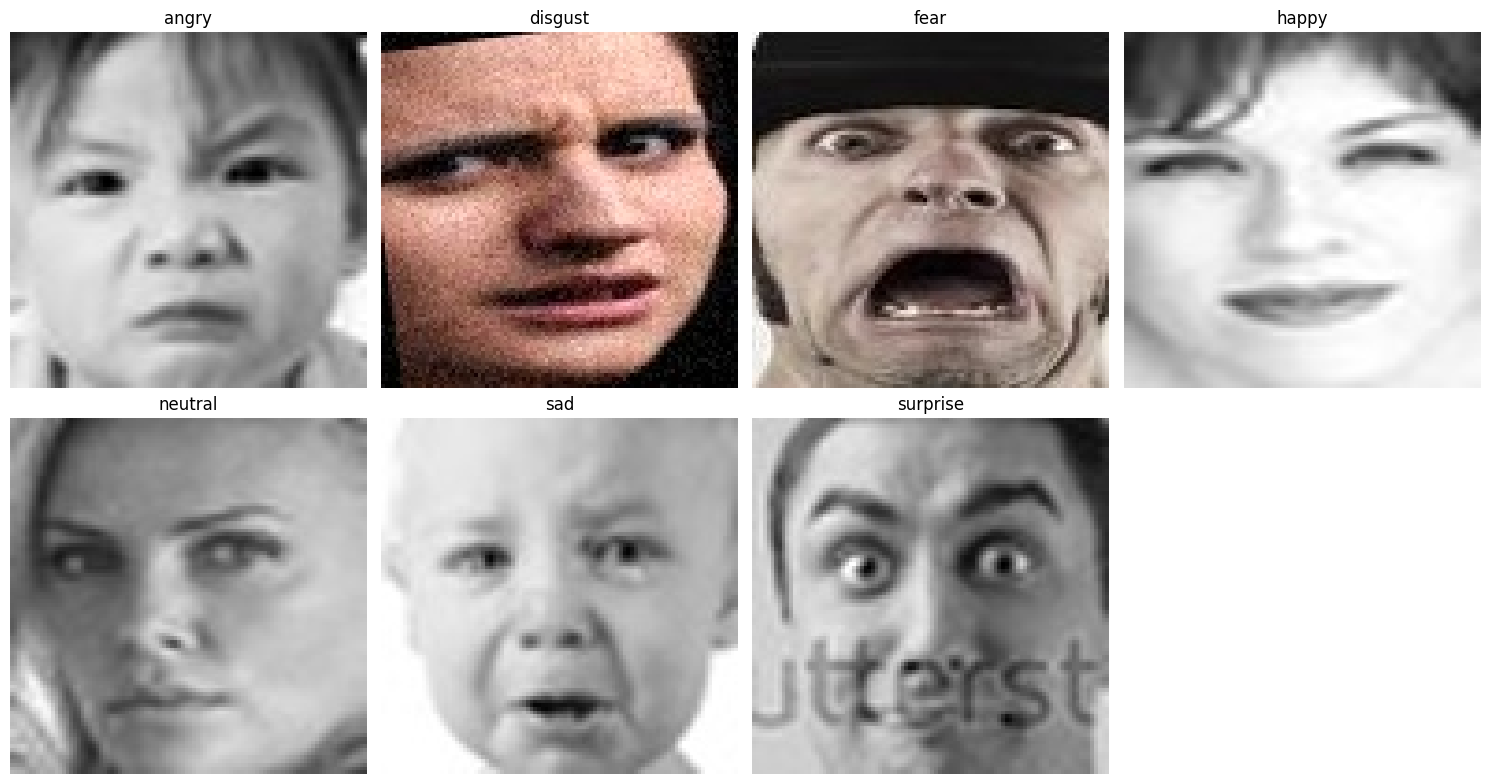

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

# Obtenemos las clases a partir de las carpetas dentro de raw
clases = sorted([carpeta.name for carpeta in ruta_dataset.iterdir() if carpeta.is_dir()])

# Creamos una figura para mostrar una imagen por clase
plt.figure(figsize=(15, 8))

# Recorremos las clases y mostramos la primera imagen encontrada en cada carpeta
for i, clase in enumerate(clases, 1):
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))

    # Tomamos la primera imagen de la carpeta
    img = Image.open(imagenes[0])

    # Mostramos la imagen en una subgráfica
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(clase)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Revisión del tamaño de las imágenes (para saber si hay homogeneidad o variabilidad)

import pandas as pd

# Lista para guardar tamaños de ejemplo
tamanos = []

# Revisamos hasta 5 imágenes por clase
for clase in clases:
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))[:5]

    for img_path in imagenes:
        img = Image.open(img_path)
        tamanos.append({
            "Clase": clase,
            "Archivo": img_path.name,
            "Ancho": img.size[0],
            "Alto": img.size[1]
        })

# Convertimos a DataFrame
tabla_tamanos = pd.DataFrame(tamanos)
tabla_tamanos.groupby("Clase")[["Ancho", "Alto"]].agg(["min", "max", "mean"])

Ancho           Alto          
           min max  mean  min max  mean
Clase                                  
angry       96  96  96.0   96  96  96.0
disgust     96  96  96.0   96  96  96.0
fear        96  96  96.0   96  96  96.0
happy       96  96  96.0   96  96  96.0
neutral     96  96  96.0   96  96  96.0
sad         96  96  96.0   96  96  96.0
surprise    96  96  96.0   96  96  96.0

## Confirmación global del tamaño de las imágenes
Se revisa si todas las imágenes del dataset mantienen las mismas dimensiones.

In [18]:
tabla_imagenes[["Ancho", "Alto"]].drop_duplicates().sort_values(by=["Ancho", "Alto"])

,Ancho,Alto
0,96,96


In [19]:
# Cargar dataset en PyTorch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Ruta del dataset
ruta_dataset = "/content/drive/MyDrive/Thinkpad/ESCOM/6.SextoSemestre/Modelado_predictivo/Clasification/processed_data"

# Transformaciones básicas
transformaciones = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])

# Cargar dataset
dataset = datasets.ImageFolder(
    root=ruta_dataset,
    transform=transformaciones
)

# Ver clases detectadas
print("Clases:", dataset.classes)

# Número total de imágenes
print("Número total de imágenes:", len(dataset))

Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Número total de imágenes: 49779


Etiqueta numérica: 0
Clase: angry
Dimensiones: torch.Size([3, 48, 48])


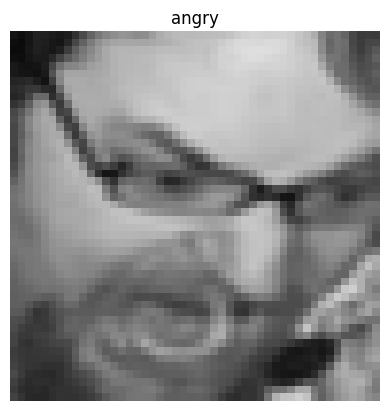

In [20]:
# Visualizar imágenes
import matplotlib.pyplot as plt

# Obtener primera imagen y etiqueta
imagen, etiqueta = dataset[0]

print("Etiqueta numérica:", etiqueta)
print("Clase:", dataset.classes[etiqueta])
print("Dimensiones:", imagen.shape)

# Mostrar imagen
plt.imshow(imagen.permute(1, 2, 0))
plt.title(dataset.classes[etiqueta])
plt.axis("off")
plt.show()

In [21]:
# Creación de DataLoader
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

# Probar un batch
imagenes, etiquetas = next(iter(loader))

print("Shape imágenes:", imagenes.shape)
print("Shape etiquetas:", etiquetas.shape)

Shape imágenes: torch.Size([32, 3, 48, 48])
Shape etiquetas: torch.Size([32])
